# Flash Attention：以分塊之法節省記憶體

> **難度：** 中等 | **時長：** 約四十分鐘

標準 attention 須計算完整之 $S \times S$ 注意力矩陣，所需記憶體為 $O(S^2)$。若序列長三萬二千 token，僅注意力分數一項，便耗四 GB 有餘——遑論 KV-Cache 與中間激活矣。

**Flash Attention** 之妙，在於從不具現此完整矩陣。其法將運算分為 SRAM 大小之塊，以 **online softmax** 逐步累積結果。所得與標準 attention 數值全同，而額外記憶體僅需 $O(S)$。

本篇所述：
1. 標準 attention 何以受限於記憶體
2. 分塊演算法——以塊處理 Q、K、V
3. Online softmax——關鍵之數學洞見
4. IO 複雜度分析——計 HBM 讀寫之數
5. FlashDecoding——優化解碼階段

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import (
    standard_attention, flash_attention_tiled, online_softmax_demo,
)
from mp_tutorial.inference_viz import (
    draw_attention_memory_comparison, draw_prefill_decode_comparison,
    draw_operator_fusion,
)
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. 標準 Attention 之記憶體難題

標準 multi-head attention 之運算如下：

$$S = QK^T / \sqrt{d_k} \quad (S \times S \text{ matrix})$$
$$A = \text{softmax}(S) \quad (S \times S \text{ matrix})$$
$$O = A \cdot V \quad (S \times d \text{ matrix})$$

其弊在於：$S$ 與 $A$ 皆為 $S \times S$ 矩陣，須存於 GPU **HBM**（高頻寬記憶體，high bandwidth memory）之中。序列愈長，記憶體之耗愈巨。

GPU 記憶體層級：
- **SRAM**（片上）：約 20 MB，約 19 TB/s——速極快而容量甚微
- **HBM**（片外）：約 80 GB，約 2 TB/s——容量宏大而速慢十倍

標準 attention 將完整 $S \times S$ 矩陣寫入 HBM，讀回以行 softmax，再寫 softmax 之果於 HBM，復讀回以算 $A \times V$。僅注意力矩陣一項，便經 **四次往返** 於遲緩之 HBM。

In [2]:
# Memory usage of the S×S attention matrix at different sequence lengths
seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

print(f"{'Seq Length':>10} | {'Attn Matrix':>15} | {'Memory (FP16)':>15} | {'Memory (FP32)':>15}")
print("-" * 65)
for s in seq_lengths:
    elements = s * s
    fp16_mb = elements * 2 / (1024**2)
    fp32_mb = elements * 4 / (1024**2)
    print(f"{s:>10,} | {s:>7,}×{s:<7,} | {fp16_mb:>12.1f} MB | {fp32_mb:>12.1f} MB")

print(f"\n→ At 128K tokens, the attention matrix alone is {131072**2 * 2 / 1024**3:.1f} GB (FP16)!")
print(f"  And this is per head, per layer. With 32 heads: {131072**2 * 2 * 32 / 1024**3:.0f} GB")

Seq Length |     Attn Matrix |   Memory (FP16) |   Memory (FP32)
-----------------------------------------------------------------
       512 |     512×512     |          0.5 MB |          1.0 MB
     1,024 |   1,024×1,024   |          2.0 MB |          4.0 MB
     2,048 |   2,048×2,048   |          8.0 MB |         16.0 MB
     4,096 |   4,096×4,096   |         32.0 MB |         64.0 MB
     8,192 |   8,192×8,192   |        128.0 MB |        256.0 MB
    16,384 |  16,384×16,384  |        512.0 MB |       1024.0 MB
    32,768 |  32,768×32,768  |       2048.0 MB |       4096.0 MB
    65,536 |  65,536×65,536  |       8192.0 MB |      16384.0 MB
   131,072 | 131,072×131,072 |      32768.0 MB |      65536.0 MB

→ At 128K tokens, the attention matrix alone is 32.0 GB (FP16)!
  And this is per head, per layer. With 32 heads: 1024 GB


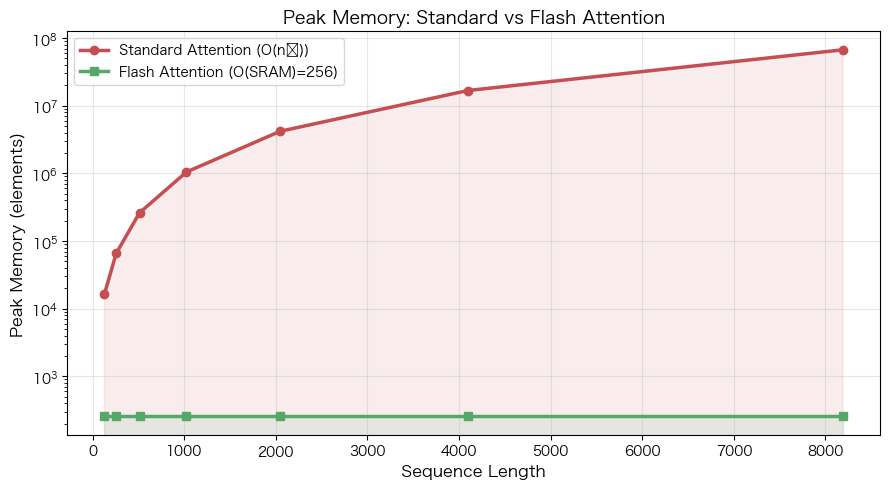

In [3]:
# Visualize: standard attention memory (O(n²)) vs Flash Attention (O(block_size²))
fig, ax = draw_attention_memory_comparison(
    seq_lengths=[128, 256, 512, 1024, 2048, 4096, 8192],
    d_model=64,
    sram_size=256,  # block_size=16 → 16×16 = 256
    title="Peak Memory: Standard vs Flash Attention"
)
plt.show()

---
## 2. Online Softmax——關鍵之數學洞見

標準 softmax 須 **遍歷兩次** 數據：
1. 求其最大值：$m = \max_i(x_i)$
2. 計算：$\text{softmax}(x_i) = e^{x_i - m} / \sum_j e^{x_j - m}$

是以須覽全部之值，方能算得任一 softmax 輸出。既如此，分塊計算何以可行？蓋 softmax 需知全局之最大值也。

**Online softmax** 解此難題：維持動態統計量（$m_{\text{running}}, \ell_{\text{running}}$），每得新塊即逐步更新：

每得新塊 $x_{\text{chunk}}$：
1. $m_{\text{new}} = \max(m_{\text{running}}, \max(x_{\text{chunk}}))$
2. $\ell_{\text{new}} = \ell_{\text{running}} \cdot e^{m_{\text{running}} - m_{\text{new}}} + \sum_j e^{x_j - m_{\text{new}}}$
3. 重新縮放累積輸出：$O_{\text{new}} = O_{\text{old}} \cdot \frac{\ell_{\text{old}} \cdot e^{m_{\text{old}} - m_{\text{new}}}}{\ell_{\text{new}}} + \frac{e^{x_{\text{chunk}} - m_{\text{new}}}}{\ell_{\text{new}}} \cdot V_{\text{chunk}}$

其要在於：每逢新最大值，先前所累積之部分結果皆經 **重新縮放** 以應其變。

In [4]:
# Demonstrate online softmax step by step
values = [2.0, 1.0, 4.0, 3.0, 0.5, 5.0, 1.5, 2.5]
chunk_size = 2

print(f"Input values: {values}")
print(f"Chunk size: {chunk_size}")
print(f"\nStandard softmax result: {F.softmax(torch.tensor(values), dim=0).tolist()}")
print("\n" + "=" * 70)

steps = online_softmax_demo(values, chunk_size=chunk_size)
for step in steps:
    print(f"\nChunk {step['chunk_idx']}: values = {step['chunk_values']}")
    print(f"  running_max = {step['running_max']:.2f}")
    print(f"  running_sum = {step['running_sum']:.4f}")
    print(f"  partial softmax = [{', '.join(f'{v:.4f}' for v in step['partial_softmax'])}]")

# Verify final result matches standard softmax
final = steps[-1]['partial_softmax']
standard = F.softmax(torch.tensor(values), dim=0).tolist()
print(f"\n✓ Online softmax matches standard: {all(abs(a-b) < 1e-5 for a, b in zip(final, standard))}")

Input values: [2.0, 1.0, 4.0, 3.0, 0.5, 5.0, 1.5, 2.5]
Chunk size: 2

Standard softmax result: [0.029377946630120277, 0.010807543061673641, 0.21707530319690704, 0.07985754311084747, 0.006555106025189161, 0.5900718569755554, 0.017818626016378403, 0.04843604564666748]


Chunk 0: values = [2.0, 1.0]
  running_max = 2.00
  running_sum = 1.3679
  partial softmax = [0.7311, 0.2689]

Chunk 1: values = [4.0, 3.0]
  running_max = 4.00
  running_sum = 1.5530
  partial softmax = [0.0871, 0.0321, 0.6439, 0.2369]

Chunk 2: values = [0.5, 5.0]
  running_max = 5.00
  running_sum = 1.5824
  partial softmax = [0.0315, 0.0116, 0.2325, 0.0855, 0.0070, 0.6319]

Chunk 3: values = [1.5, 2.5]
  running_max = 5.00
  running_sum = 1.6947
  partial softmax = [0.0294, 0.0108, 0.2171, 0.0799, 0.0066, 0.5901, 0.0178, 0.0484]

✓ Online softmax matches standard: True


---
## 3. Flash Attention：分塊運算

Flash Attention 將 online softmax 與分塊矩陣乘法合而為一：

```
for each Q block (rows i to i+B_r):
    initialize: O_i = 0, m_i = -inf, l_i = 0
    for each KV block (rows j to j+B_c):
        1. Load Q_i, K_j, V_j from HBM into SRAM
        2. Compute S_ij = Q_i @ K_j^T / sqrt(d)   (B_r × B_c tile)
        3. Update online softmax: m_new, l_new
        4. Rescale O_i and add new contribution: O_i += softmax_tile @ V_j
    5. Write O_i back to HBM
```

注意力分數塊 $S_{ij}$ 僅 $B_r \times B_c$ 之大——盡納於 SRAM 之內，**從不寫入 HBM**。

In [5]:
# Run our simplified Flash Attention and compare with standard
torch.manual_seed(42)
S, d = 8, 4  # small for readability
Q = torch.randn(S, d)
K = torch.randn(S, d)
V = torch.randn(S, d)

# Standard attention
out_std, attn_weights, std_peak_mem = standard_attention(Q, K, V)

# Flash attention with different block sizes
for block_size in [2, 4]:
    out_flash, flash_peak_mem, hbm_reads, hbm_writes = flash_attention_tiled(
        Q, K, V, block_size=block_size
    )
    
    max_diff = (out_std - out_flash).abs().max().item()
    print(f"Block size {block_size}:")
    print(f"  Peak SRAM usage: {flash_peak_mem} elements (vs {std_peak_mem} for standard)")
    print(f"  Memory reduction: {std_peak_mem / flash_peak_mem:.1f}×")
    print(f"  HBM reads: {hbm_reads}, writes: {hbm_writes}")
    print(f"  Max difference from standard: {max_diff:.8f}")
    print()

Block size 2:
  Peak SRAM usage: 28 elements (vs 64 for standard)
  Memory reduction: 2.3×
  HBM reads: 288, writes: 32
  Max difference from standard: 0.00000006

Block size 4:
  Peak SRAM usage: 64 elements (vs 64 for standard)
  Memory reduction: 1.0×
  HBM reads: 160, writes: 32
  Max difference from standard: 0.00000009



In [6]:
# Verify correctness at larger scale
torch.manual_seed(0)
S, d = 64, 32
Q = torch.randn(S, d)
K = torch.randn(S, d)
V = torch.randn(S, d)

out_std, _, std_mem = standard_attention(Q, K, V)
out_flash, flash_mem, _, _ = flash_attention_tiled(Q, K, V, block_size=8)

print(f"Sequence length: {S}, dimension: {d}")
print(f"Standard peak memory: {std_mem:,} elements ({S}×{S} attention matrix)")
print(f"Flash peak SRAM:      {flash_mem:,} elements")
print(f"Memory reduction:     {std_mem / flash_mem:.0f}×")
print(f"Max output difference: {(out_std - out_flash).abs().max().item():.2e}")
print(f"\n✓ Outputs match (within numerical precision)")

Sequence length: 64, dimension: 32
Standard peak memory: 4,096 elements (64×64 attention matrix)
Flash peak SRAM:      832 elements
Memory reduction:     5×
Max output difference: 4.17e-07

✓ Outputs match (within numerical precision)


---
## 4. IO 複雜度分析

衡量之關鍵非在 FLOPs（兩法運算量相同），乃在 **HBM 存取次數**。

| 演算法 | HBM 讀取 | HBM 寫入 | HBM 存取總量 |
|-----------|-----------|------------|------------------|
| 標準  | $O(S^2 d + S^2)$ | $O(S^2 + Sd)$ | $O(S^2 d)$ |
| Flash     | $O(S^2 d^2 / M)$ | $O(Sd)$ | $O(S^2 d^2 / M)$ |

其中 $M$ 為 SRAM 之大。實務上 $M \gg d^2$（SRAM 約 20MB，$d^2$ 於 $d=128$ 時僅約 16K），故 Flash Attention 之 HBM 存取量大為減少。

改善倍率：$\frac{S^2 d}{S^2 d^2 / M} = \frac{M}{d}$

以常見數值計之（$M = 100\text{KB SRAM per SM}$，$d = 128$）：改善約 $800\times$，每塊之 HBM 存取大減。

In [7]:
# Concrete IO analysis
d = 128  # typical head dimension
M_sram = 100 * 1024  # 100 KB SRAM per SM (in elements, assuming FP16)
# block_size ~ sqrt(M / d) to maximize tile size
block_size = int(math.sqrt(M_sram / (4 * d)))  # factor 4: Q + K + V + S tiles

print(f"Head dimension: {d}")
print(f"SRAM per SM: {M_sram:,} elements")
print(f"Optimal block size: ~{block_size}")

print(f"\n{'Seq Length':>10} | {'Standard HBM':>15} | {'Flash HBM':>15} | {'Reduction':>10}")
print("-" * 60)
for S in [1024, 4096, 16384, 65536]:
    std_hbm = S * S * d + S * S + S * d  # read QKV + write S + write O
    # Flash: each Q block loads all KV blocks from HBM
    n_blocks = S // block_size
    flash_hbm = n_blocks * (block_size * d + S * d * 2) + S * d  # Q tiles + KV scans + write O
    
    print(f"{S:>10,} | {std_hbm/1e6:>12.1f} M | {flash_hbm/1e6:>12.1f} M | {std_hbm/flash_hbm:>9.1f}×")

Head dimension: 128
SRAM per SM: 102,400 elements
Optimal block size: ~14

Seq Length |    Standard HBM |       Flash HBM |  Reduction
------------------------------------------------------------
     1,024 |        135.4 M |         19.4 M |       7.0×
     4,096 |       2164.8 M |        307.2 M |       7.0×
    16,384 |      34630.3 M |       4911.5 M |       7.1×
    65,536 |     554059.2 M |      78550.9 M |       7.1×


---
## 5. FlashDecoding：優化解碼階段

於 **decode**（逐 token 生成）階段，Flash Attention 遇一難題：

- Query 僅含 **一個 token** ——Q 僅一行——僅一 thread block 之工作量
- K/V 含 $S$ 個 token（完整上下文）——數據甚多
- 以標準 Flash Attention 處之，須依序遍歷 KV 塊——**GPU 利用率低下**

**FlashDecoding**（Dao 等，2023）解此困局，沿 **KV 序列維度** 並行化：

1. 將 K/V 沿序列維度分為數段
2. 各 thread block 計算 Q 對其 KV 段之 attention（部分結果）
3. 最終以 online softmax 歸約合併諸部分結果

如此一來，decode 階段 GPU 利用率大增——全部 SM 並行處理各 KV 段，不復受限於單一 query token 之瓶頸。

In [8]:
# Simulate FlashDecoding parallelism
torch.manual_seed(42)
S_kv = 4096  # KV cache length
d = 128
n_splits = 16  # number of parallel workers

Q = torch.randn(1, d)  # single query token
K = torch.randn(S_kv, d)
V = torch.randn(S_kv, d)

# Standard decode: sequential over KV
scores_full = Q @ K.T / math.sqrt(d)  # 1 × S_kv
attn_full = F.softmax(scores_full, dim=-1)
out_full = attn_full @ V  # 1 × d

# FlashDecoding: parallel over KV splits
chunk_size = S_kv // n_splits
partial_outputs = []
partial_maxes = []
partial_sums = []

for i in range(n_splits):
    start = i * chunk_size
    end = start + chunk_size
    K_chunk = K[start:end]
    V_chunk = V[start:end]
    
    scores = Q @ K_chunk.T / math.sqrt(d)  # 1 × chunk_size
    chunk_max = scores.max()
    exp_scores = torch.exp(scores - chunk_max)
    chunk_sum = exp_scores.sum()
    chunk_out = (exp_scores / chunk_sum) @ V_chunk
    
    partial_outputs.append(chunk_out)
    partial_maxes.append(chunk_max)
    partial_sums.append(chunk_sum)

# Reduction: combine partial results with online softmax
global_max = max(partial_maxes)
combined_out = torch.zeros(1, d)
total_sum = torch.tensor(0.0)

for out, m, s in zip(partial_outputs, partial_maxes, partial_sums):
    rescale = torch.exp(m - global_max) * s
    total_sum += rescale
    combined_out += out * rescale

combined_out /= total_sum

print(f"KV length: {S_kv}, splits: {n_splits}, chunk size: {chunk_size}")
print(f"\nStandard decode:   1 worker processes {S_kv} KV tokens sequentially")
print(f"FlashDecoding:     {n_splits} workers process {chunk_size} KV tokens each in parallel")
print(f"\nMax difference: {(out_full - combined_out).abs().max().item():.2e}")
print(f"✓ Results match — FlashDecoding gives {n_splits}× more parallelism")

KV length: 4096, splits: 16, chunk size: 256

Standard decode:   1 worker processes 4096 KV tokens sequentially
FlashDecoding:     16 workers process 256 KV tokens each in parallel

Max difference: 1.04e-07
✓ Results match — FlashDecoding gives 16× more parallelism


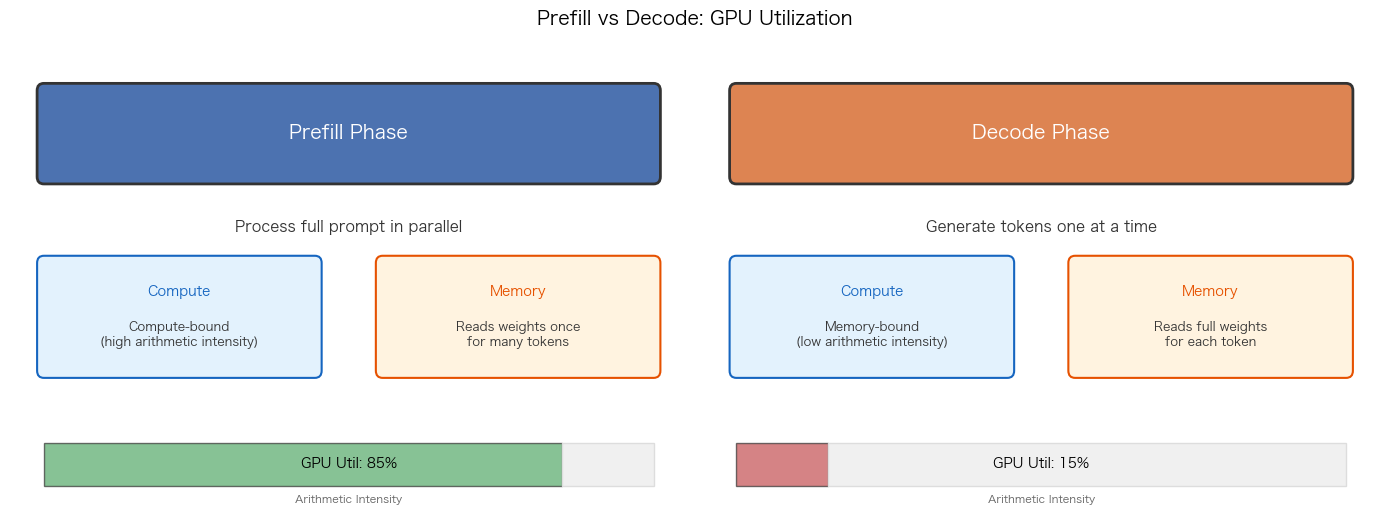

FlashDecoding addresses the decode phase's low GPU utilization by
parallelizing across the KV sequence dimension instead of being
bottlenecked by having only 1 query token.


In [9]:
# Compare GPU utilization: standard vs FlashDecoding
fig, axes = draw_prefill_decode_comparison(title="Prefill vs Decode: GPU Utilization")
plt.show()

print("FlashDecoding addresses the decode phase's low GPU utilization by")
print("parallelizing across the KV sequence dimension instead of being")
print("bottlenecked by having only 1 query token.")

---
## 總結

| 概念 | 標準 Attention | Flash Attention |
|---------|-------------------|----------------|
| **峰值記憶體** | $O(S^2)$——完整注意力矩陣 | $O(B_r \times B_c)$——僅一塊 |
| **HBM 存取** | $O(S^2 d)$ | $O(S^2 d^2 / M)$ |
| **數值結果** | （基準） | 全同（精確而非近似） |
| **解碼優化** | 依序遍歷 KV | FlashDecoding：並行分段 KV |

### 要旨提要：
- Flash Attention **非近似之法**——其結果與標準 attention 分毫不差
- 改善之源在於 **減少 HBM 往返**，而非減少運算量
- **Online softmax** 乃使分塊可行之數學巧思
- **FlashDecoding** 將此理推廣至解碼階段，沿 KV 序列並行

### Flash Attention 實務應用

```python
# PyTorch >= 2.0 includes Flash Attention automatically:
F.scaled_dot_product_attention(Q, K, V)  # auto-selects Flash Attention when possible

# Or use the flash-attn library directly:
from flash_attn import flash_attn_func
output = flash_attn_func(Q, K, V, causal=True)
```

### 延伸閱讀
- [FlashAttention: Fast and Memory-Efficient Exact Attention (Dao et al., 2022)](https://arxiv.org/abs/2205.14135)
- [FlashAttention-2 (Dao, 2023)](https://arxiv.org/abs/2307.08691)
- [FlashDecoding (Dao et al., 2023)](https://crfm.stanford.edu/2023/10/12/flashdecoding.html)
- 下一篇：**[02-continuous-batching](02-continuous-batching.ipynb)** ——優化請求調度